In [1]:
print("Day 1 - Dengue Genomic Analysis Project")
print("Starting bioinformatics pipeline")

Day 1 - Dengue Genomic Analysis Project
Starting bioinformatics pipeline


In [2]:
import subprocess
subprocess.run(["pip", "install", "biopython"])


CompletedProcess(args=['pip', 'install', 'biopython'], returncode=0)

In [3]:
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
import pandas as pd
import matplotlib.pyplot as plt
print("All libraries loaded successfully!")


All libraries loaded successfully!


# Dengue Virus Genomic Analysis

## Background

Dengue fever is a mosquito-borne viral disease caused by the dengue 
virus (DENV), transmitted primarily by Aedes aegypti mosquitoes. 
It is a major public health concern globally, with an estimated 
400 million infections occurring annually.

The dengue virus exists as four genetically distinct serotypes: 
DENV-1, DENV-2, DENV-3, and DENV-4. While all four serotypes 
cause dengue fever, they are sufficiently different at the genomic 
level that infection with one serotype does not confer immunity 
against the others. This phenomenon — known as the lack of 
cross-protective immunity — means that individuals in endemic 
regions like Tamil Nadu can be infected up to four times in 
their lifetime.

A second infection by a different serotype carries a significantly 
higher risk of severe dengue (dengue haemorrhagic fever), which 
can be fatal. This makes understanding the genomic differences 
between serotypes a critical research question.

## Research Question
How genomically distinct are the four dengue virus serotypes, 
and can these differences be visualised through phylogenetic 
analysis and GC content comparison?

## Step 1 - Loading and Exploring the Sequences


In [3]:
from Bio import SeqIO
import os

data_path = r"C:\Users\Gaayathri PS\OneDrive\Documents\DENGUE_PROJECT\Data"

print("=== DENV-1 Sequences ===")
for record in SeqIO.parse(os.path.join(data_path, "DENV1.fasta"), "fasta"):
    print(f"ID: {record.id} | Length: {len(record.seq)} bp")

=== DENV-1 Sequences ===
ID: MW315195.1 | Length: 10734 bp
ID: PX297362.1 | Length: 10734 bp
ID: MW362474.1 | Length: 10735 bp
ID: KR052012.1 | Length: 10714 bp
ID: AF226685.2 | Length: 10735 bp


In [2]:
import os
print(os.path.expanduser("~"))

C:\Users\Gaayathri PS


In [4]:
serotypes = ["DENV1", "DENV2", "DENV3", "DENV4"]

for serotype in serotypes:
    print(f"\n=== {serotype} Sequences ===")
    for record in SeqIO.parse(os.path.join(data_path, f"{serotype}.fasta"), "fasta"):
        print(f"ID: {record.id} | Length: {len(record.seq)} bp")


=== DENV1 Sequences ===
ID: MW315195.1 | Length: 10734 bp
ID: PX297362.1 | Length: 10734 bp
ID: MW362474.1 | Length: 10735 bp
ID: KR052012.1 | Length: 10714 bp
ID: AF226685.2 | Length: 10735 bp

=== DENV2 Sequences ===
ID: PV752130.1 | Length: 10723 bp
ID: PQ657766.1 | Length: 10723 bp
ID: MH822944.2 | Length: 10723 bp
ID: MZ008467.1 | Length: 10724 bp
ID: KP406804.1 | Length: 10712 bp

=== DENV3 Sequences ===
ID: PX297385.1 | Length: 10709 bp
ID: PV918782.1 | Length: 10707 bp
ID: MH051731.1 | Length: 10766 bp
ID: MH891766.1 | Length: 10764 bp
ID: JX669494.1 | Length: 10710 bp

=== DENV4 Sequences ===
ID: MG601754.1 | Length: 10772 bp
ID: KF041260.1 | Length: 10652 bp
ID: JQ922560.1 | Length: 10739 bp
ID: JN983813.1 | Length: 10649 bp
ID: AY618993.1 | Length: 10653 bp


In [5]:
import pandas as pd

serotypes = ["DENV1", "DENV2", "DENV3", "DENV4"]

data = []

for serotype in serotypes:
    for record in SeqIO.parse(os.path.join(data_path, f"{serotype}.fasta"), "fasta"):
        data.append({
            "Accession": record.id,
            "Serotype": serotype,
            "Length": len(record.seq)
        })

df = pd.DataFrame(data)
print(df)

     Accession Serotype  Length
0   MW315195.1    DENV1   10734
1   PX297362.1    DENV1   10734
2   MW362474.1    DENV1   10735
3   KR052012.1    DENV1   10714
4   AF226685.2    DENV1   10735
5   PV752130.1    DENV2   10723
6   PQ657766.1    DENV2   10723
7   MH822944.2    DENV2   10723
8   MZ008467.1    DENV2   10724
9   KP406804.1    DENV2   10712
10  PX297385.1    DENV3   10709
11  PV918782.1    DENV3   10707
12  MH051731.1    DENV3   10766
13  MH891766.1    DENV3   10764
14  JX669494.1    DENV3   10710
15  MG601754.1    DENV4   10772
16  KF041260.1    DENV4   10652
17  JQ922560.1    DENV4   10739
18  JN983813.1    DENV4   10649
19  AY618993.1    DENV4   10653


In [6]:
from Bio.SeqUtils import gc_fraction

data = []

for serotype in serotypes:
    for record in SeqIO.parse(os.path.join(data_path, f"{serotype}.fasta"), "fasta"):
        gc = round(gc_fraction(record.seq) * 100, 2)
        data.append({
            "Accession": record.id,
            "Serotype": serotype,
            "Length": len(record.seq),
            "GC Content (%)": gc
        })

df = pd.DataFrame(data)
print(df)

     Accession Serotype  Length  GC Content (%)
0   MW315195.1    DENV1   10734           46.28
1   PX297362.1    DENV1   10734           46.62
2   MW362474.1    DENV1   10735           46.62
3   KR052012.1    DENV1   10714           46.76
4   AF226685.2    DENV1   10735           46.44
5   PV752130.1    DENV2   10723           45.73
6   PQ657766.1    DENV2   10723           45.77
7   MH822944.2    DENV2   10723           45.83
8   MZ008467.1    DENV2   10724           45.63
9   KP406804.1    DENV2   10712           46.07
10  PX297385.1    DENV3   10709           46.61
11  PV918782.1    DENV3   10707           46.74
12  MH051731.1    DENV3   10766           46.38
13  MH891766.1    DENV3   10764           46.66
14  JX669494.1    DENV3   10710           46.50
15  MG601754.1    DENV4   10772           47.34
16  KF041260.1    DENV4   10652           47.44
17  JQ922560.1    DENV4   10739           47.56
18  JN983813.1    DENV4   10649           47.19
19  AY618993.1    DENV4   10653         

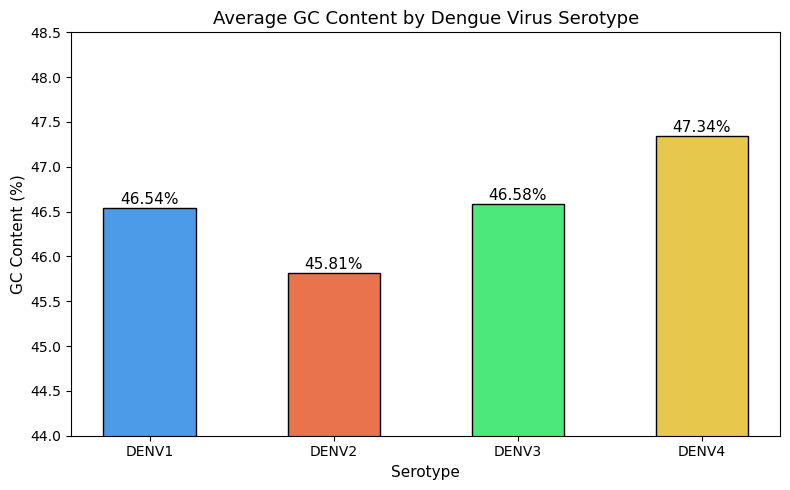

Chart saved!


In [7]:
import matplotlib.pyplot as plt

# Calculate average GC per serotype
avg_gc = df.groupby("Serotype")["GC Content (%)"].mean().round(2)

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(avg_gc.index, avg_gc.values, 
               color=["#4C9BE8", "#E8734C", "#4CE87B", "#E8C84C"],
               edgecolor="black", width=0.5)

# Add value labels on top of each bar
for bar, val in zip(bars, avg_gc.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.05, 
             f"{val}%", ha="center", fontsize=11)

plt.title("Average GC Content by Dengue Virus Serotype", fontsize=13)
plt.xlabel("Serotype", fontsize=11)
plt.ylabel("GC Content (%)", fontsize=11)
plt.ylim(44, 48.5)
plt.tight_layout()
plt.savefig(r"C:\Users\Gaayathri PS\OneDrive\Documents\DENGUE_PROJECT\images\GC_content.png", dpi=300)
plt.show()

print("Chart saved!")